In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
#import data

ruta_importacion = 'C:/Users/regis/OneDrive/Maestria en ciencias de datos/03. Probabilidad y Estadistica/final_project/bases/importacion.xlsx'
importacion = pd.read_excel(ruta_importacion, sheet_name='Sheet1')

ruta_dosis= "C:/Users/regis/OneDrive/Maestria en ciencias de datos/03. Probabilidad y Estadistica/final_project/bases/product_dosages.xlsx"
dosis = pd.read_excel(ruta_dosis, sheet_name='Sheet1')

ruta_senave = "C:/Users/regis/OneDrive/Maestria en ciencias de datos/03. Probabilidad y Estadistica/final_project/bases/senave.xlsx"
senave = pd.read_excel(ruta_senave, sheet_name='Sheet1')

Data Mining

In [3]:
## unificar el formato de columnas
importacion.columns = importacion.columns.str.lower()
importacion.columns = importacion.columns.str.replace(' ', '_')
importacion.columns = importacion.columns.str.replace('(', '')
importacion.columns = importacion.columns.str.replace(')', '')

dosis.columns = dosis.columns.str.lower()
dosis.columns = dosis.columns.str.replace(' ', '_')
dosis.columns = dosis.columns.str.replace('(', '')
dosis.columns = dosis.columns.str.replace(')', '')

senave.columns = senave.columns.str.lower()
senave.columns = senave.columns.str.replace(' ', '_')
senave.columns = senave.columns.str.replace('(', '')
senave.columns = senave.columns.str.replace(')', '')

In [4]:
## correcciones de formato en columnas

importacion.loc[:,'brand'] = importacion['brand'].str.lower()
importacion.loc[:,'brand'] = importacion['brand'].str.replace('®', '')
importacion.loc[:,'brand'] = importacion['brand'].str.replace('™', '')
importacion.loc[:,'type'] = importacion['type'].str.lower()
importacion.loc[:,'product_type'] = importacion['product_type'].str.lower()
for columns in importacion.columns:
    importacion[columns] = importacion[columns].astype(str).str.strip()

senave.loc[:,'p.activo'] = senave['p.activo'].str.lower()
senave.loc[:,'producto'] = senave['producto'].str.lower()
senave.loc[:,'producto'] = senave['producto'].str.replace('®', '')
senave.loc[:,'producto'] = senave['producto'].str.replace('™', '')
senave.loc[:,'p.activo'] = senave['p.activo'].astype(str).str.replace(r'\.000(?=\D|$)', '', regex=True).str.strip()
for columns in senave.columns:
    senave[columns] = senave[columns].astype(str).str.strip()

dosis.loc[:,'producto'] = dosis['producto'].str.lower()
dosis.loc[:,'producto'] = dosis['producto'].str.replace('®', '')
dosis.loc[:,'producto'] = dosis['producto'].str.replace('™', '')
for columns in dosis.columns:
    dosis[columns] = dosis[columns].astype(str).str.strip()

In [5]:
## merge!

importacion = importacion.merge(
    dosis[['producto', 'dosis_l/ha']],
    how='left',
    left_on='brand',
    right_on='producto'
)

In [6]:
importacion = importacion.drop(columns=['producto'])

In [7]:
importacion = importacion.merge(
    senave[['producto', 'p.activo']],
    how='left',
    left_on='brand',
    right_on='producto'
)

In [8]:
importacion.loc[importacion['brand'] == 'thiametoxan 75','p.activo'] = 'thiametoxam 75 %' 
importacion.loc[importacion['brand'] == 'thiametoxan 75','producto'] = 'thiametoxam 75 %' 

In [9]:
importacion = importacion.drop(columns=['producto'])

In [10]:
##unificar 
importacion['p.activo'] = importacion['p.activo'].str.replace('thiametoxan', 'thiametoxam')
importacion['p.activo'] = importacion['p.activo'].str.replace('thiamethoxam', 'thiametoxam')
importacion['p.activo'] = importacion['p.activo'].str.replace('thiametoxam', 'tiametoxam')

In [11]:
## categorizar productos por activo
importacion.loc[importacion['p.activo'].str.contains('imidacloprid', na=False), 'ai_category'] = 'imidacloprid'
importacion.loc[importacion['p.activo'].str.contains('acefato', na=False), 'ai_category'] = 'acefato'
importacion.loc[importacion['p.activo'].str.contains('dinotefuran', na=False), 'ai_category'] = 'dinotefuran'
importacion.loc[importacion['p.activo'].str.contains('acetamiprid', na=False), 'ai_category'] = 'acetamiprid'
importacion.loc[importacion['p.activo'].str.contains('fipronil', na=False), 'ai_category'] = 'fipronil'
importacion.loc[importacion['p.activo'].str.contains('pirimicarb', na=False), 'ai_category'] = 'pirimicarb'
importacion.loc[importacion['p.activo'].str.contains('carbosulfan', na=False), 'ai_category'] = 'carbosulfan'
importacion.loc[importacion['p.activo'].str.contains('tiametoxam', na=False), 'ai_category'] = 'tiametoxam'
importacion.loc[importacion['p.activo'].str.contains('benzoato', na=False), 'ai_category'] = 'benzoato'

In [12]:
importacion.loc[:,'product_category'] = np.where(importacion['p.activo'].str.contains(';'),'mezcla', 'simple')

In [13]:
#seleccion de columnas
selected_columns = ['ai_category','product_category','imported_volume','dosis_l/ha','cif']

data = importacion[selected_columns]


In [14]:
data['imported_volume'] = pd.to_numeric(data['imported_volume'], errors='coerce')
data['dosis_l/ha'] = pd.to_numeric(data['dosis_l/ha'], errors='coerce')
data['cif'] = pd.to_numeric(data['cif'], errors='coerce')

In [15]:
## definir area tratada 
data.loc[:,'treated_area'] = round(data['imported_volume'] / data['dosis_l/ha'],0)

In [16]:
# detectar outliers en treated_area usando método IQR
serie = data['treated_area'].dropna()
Q1 = serie.quantile(0.25)
Q3 = serie.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask_outliers = (data['treated_area'] < lower_bound) | (data['treated_area'] > upper_bound)
outliers = data.loc[mask_outliers]

data2 = data.loc[~mask_outliers]

Analisis descriptivo

In [17]:
# variables cualitativas tabla de frecuencia
freq_table = data2.groupby(['ai_category', 'product_category']).agg(
    registros=('treated_area', 'count'),
    treated_area_total=('treated_area', 'sum')
).reset_index()

freq_table = freq_table.sort_values(by='treated_area_total', ascending=False)
freq_table.loc[:,'tretaed_area_total_acumulated'] = freq_table['treated_area_total'].cumsum()
freq_table.loc[:,'frequency'] = freq_table['treated_area_total'] / freq_table['treated_area_total'].sum()
freq_table.loc[:,'frequency_acumulated'] = freq_table['frequency'].cumsum()

In [18]:
freq_table.to_excel('C:/Users/regis/OneDrive/Maestria en ciencias de datos/03. Probabilidad y Estadistica/final_project/tabla_frecuencia.xlsx', index = False)

In [19]:
# variables cuantitativas

data_stats = data2[['treated_area', 'cif']].agg(['count', 'mean', 'median', 'std', 'min', 'max']).rename(index = {
    'count': 'cantidad',
    'mean': 'promedio',
    'median': 'mediana',
    'std': 'desvio_std',
    'min': 'minimo',
    'max': 'maximo'
})

In [20]:
data_stats

,treated_area,cif
cantidad,982.000000,982.000000
promedio,78472.443992,12.047263
mediana,48000.000000,10.332229
desvio_std,81635.137091,7.206341
minimo,540.000000,3.277521
maximo,314286.000000,87.416093


In [21]:
data_stats.to_excel('C:/Users/regis/OneDrive/Maestria en ciencias de datos/03. Probabilidad y Estadistica/final_project/data_stats.xlsx', index = True)

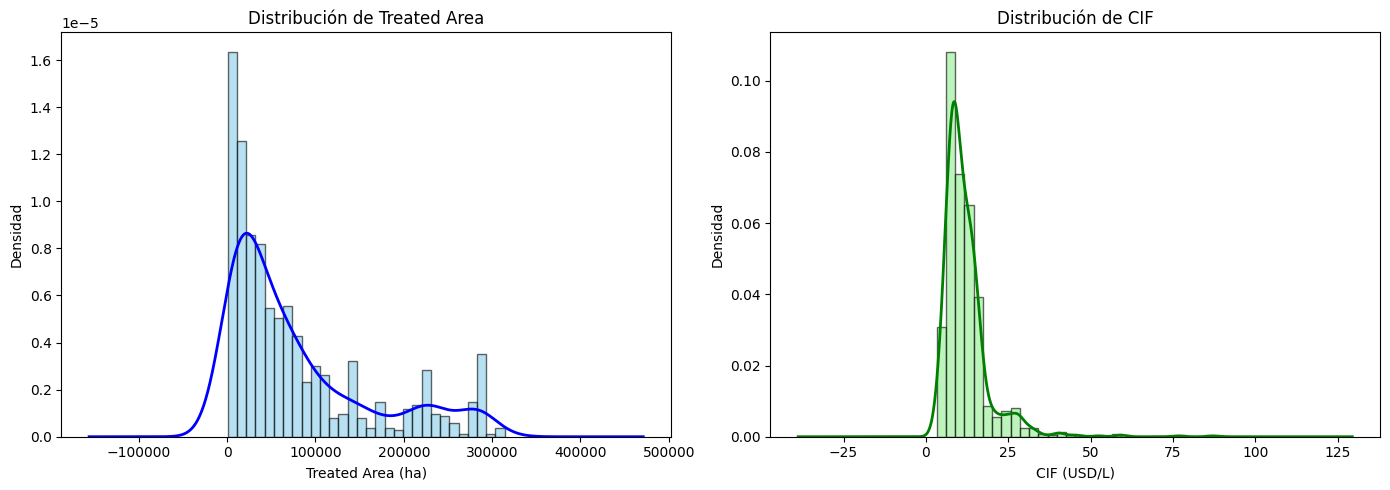

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE para treated_area
axes[0].hist(data2['treated_area'].dropna(), bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
data2['treated_area'].dropna().plot(kind='kde', ax=axes[0], color='blue', linewidth=2)
axes[0].set_title('Distribución de Treated Area')
axes[0].set_xlabel('Treated Area (ha)')
axes[0].set_ylabel('Densidad')

# Histograma con KDE para cif
axes[1].hist(data2['cif'].dropna(), bins=30, density=True, alpha=0.6, color='lightgreen', edgecolor='black')
data2['cif'].dropna().plot(kind='kde', ax=axes[1], color='green', linewidth=2)
axes[1].set_title('Distribución de CIF')
axes[1].set_xlabel('CIF (USD/L)')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

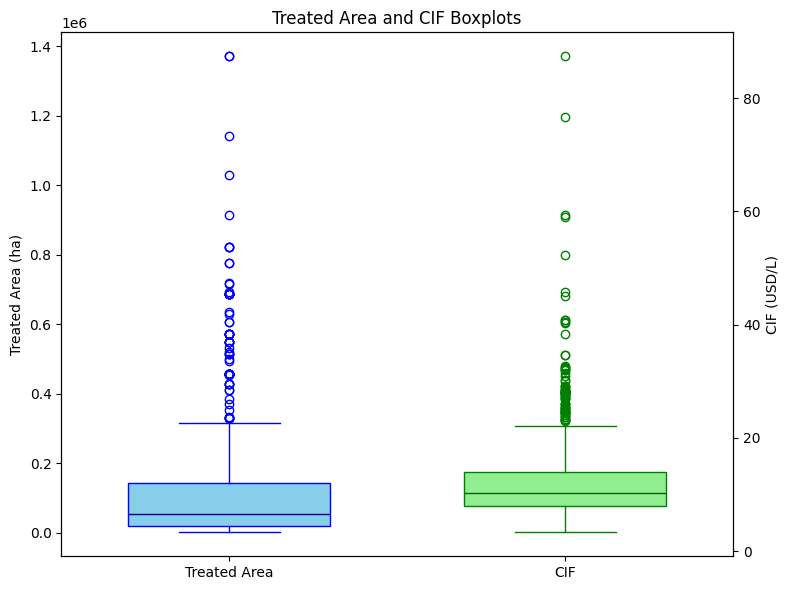

In [23]:
fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()

ax1.boxplot(data['treated_area'].dropna(), positions=[1], widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='blue'),
            medianprops=dict(color='navy'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markeredgecolor='blue'))

ax2.boxplot(data['cif'].dropna(), positions=[2], widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='green'),
            medianprops=dict(color='darkgreen'),
            whiskerprops=dict(color='green'),
            capprops=dict(color='green'),
            flierprops=dict(markeredgecolor='green'))

ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Treated Area', 'CIF'])
ax1.set_ylabel('Treated Area (ha)')
ax2.set_ylabel('CIF (USD/L)')
ax1.set_title('Treated Area and CIF Boxplots')

plt.tight_layout()
plt.show()

Estimacion de intervalos de confianza

In [24]:
#estimacion de la media poblacional del area tratada con un 95% de confianza
treated_area = data2['treated_area']
n = treated_area.shape[0]
mean_treated_area = treated_area.mean()
std_treated_area = treated_area.std(ddof=1)

alpha = 0.05
df = n - 1
t_crit = stats.t.ppf(1 - alpha / 2, df)
se = std_treated_area / np.sqrt(n)

ci_lower = mean_treated_area - t_crit * se
ci_upper = mean_treated_area + t_crit * se

print(f"Media de treated_area: {mean_treated_area:.2f}")
print(f"Intervalo de confianza 95% para la media poblacional: ({ci_lower:.2f}, {ci_upper:.2f})")

Media de treated_area: 78472.44
Intervalo de confianza 95% para la media poblacional: (73360.27, 83584.62)


In [33]:
data2 = data2[data2['ai_category']== 'dinotefuran']

In [34]:
#estimacion de la media poblacional del CIF con un 95% de confianza
CIF = data2['cif']
n = CIF.shape[0]
mean_cif = CIF.mean()
std_cif = CIF.std(ddof=1)

alpha = 0.05
df = n - 1
t_crit = stats.t.ppf(1 - alpha / 2, df)
se = std_cif / np.sqrt(n)

ci_lower = mean_cif - t_crit * se
ci_upper = mean_cif + t_crit * se

print(f"Media de CIF: {mean_cif:.2f}")
print(f"Intervalo de confianza 95% para la media poblacional: ({ci_lower:.2f}, {ci_upper:.2f})")

Media de CIF: 19.47
Intervalo de confianza 95% para la media poblacional: (17.02, 21.93)


In [38]:
# intervalo de confianza para la proporción de cada categoría en product_category
counts = data2['product_category'].value_counts()
n = counts.sum()

z = stats.norm.ppf(1 - alpha / 2)

proportions = counts / n
cis = proportions.apply(lambda p: (
    max(0, p - z * np.sqrt(p * (1 - p) / n)),
    min(1, p + z * np.sqrt(p * (1 - p) / n))
))

print("Proporciones y sus IC 95%:")
for category, prop in proportions.items():
    ci_lower, ci_upper = cis[category]
    print(f"{category}: {prop:.4f} (IC95%: {ci_lower:.4f}, {ci_upper:.4f})")

Proporciones y sus IC 95%:
simple: 0.5385 (IC95%: 0.4030, 0.6740)
mezcla: 0.4615 (IC95%: 0.3260, 0.5970)


Prueba de hipotesis

In [36]:
# Prueba T de una cola (por la izquierda)
# H0: μ = 23.2
# H1: μ < 23.2
cif_values = data2['cif']
test_mean = 23.2

n_cif = cif_values.shape[0]
mean_cif = cif_values.mean()
std_cif = cif_values.std(ddof=1)
se_cif = std_cif / np.sqrt(n_cif)
t_stat = (mean_cif - test_mean) / se_cif
df_cif = n_cif - 1

t_stat_one_tail_left = (mean_cif - test_mean) / se_cif
p_value_one_tail_left = stats.t.cdf(t_stat_one_tail_left, df_cif)

print(f"Prueba T de una cola (por la izquierda)")
print(f"H0: μ = 23.2")
print(f"H1: μ < 23.2")
print(f"\nn = {n_cif}")
print(f"media CIF = {mean_cif:.4f}")
print(f"desviación estándar CIF = {std_cif:.4f}")
print(f"t estadístico = {t_stat_one_tail_left:.4f}")
print(f"valor p (unilateral) = {p_value_one_tail_left:.4e}")
print(f"t crítico 95% = {-t_crit:.4f}")

if p_value_one_tail_left < alpha:
    print(f"\n✓ Se rechaza la hipótesis nula H0: μ = 23.2")
    print(f"Conclusión: Existe evidencia significativa de que el CIF medio es menor a 23.2 (p < {alpha})")
else:
    print(f"\n✗ No se rechaza la hipótesis nula H0: μ = 23.2")
    print(f"Conclusión: No existe evidencia significativa de que el CIF medio sea menor a 23.2 (p ≥ {alpha})")

Prueba T de una cola (por la izquierda)
H0: μ = 23.2
H1: μ < 23.2

n = 52
media CIF = 19.4730
desviación estándar CIF = 8.8154
t estadístico = -3.0488
valor p (unilateral) = 1.8188e-03
t crítico 95% = -2.0076

✓ Se rechaza la hipótesis nula H0: μ = 23.2
Conclusión: Existe evidencia significativa de que el CIF medio es menor a 23.2 (p < 0.05)


In [37]:
for category, p0 in [('mezcla', 0.4332), ('simple', 0.5668)]:
    indicator = (data2['product_category'] == category).astype(float)
    n_cat = indicator.shape[0]
    mean_prop = indicator.mean()
    std_prop = indicator.std(ddof=1)
    se_prop = std_prop / np.sqrt(n_cat)
    t_crit_cat = stats.t.ppf(1 - alpha / 2, n_cat - 1)
    t_stat_cat = (mean_prop - p0) / se_prop
    p_value_cat = 2 * stats.t.sf(abs(t_stat_cat), n_cat - 1)
    ci_lower_cat = mean_prop - t_crit_cat * se_prop
    ci_upper_cat = mean_prop + t_crit_cat * se_prop

    print(f"Categoría: {category}")
    print(f"Proporción observada: {mean_prop:.6f}")
    print(f"Proporción de prueba: {p0:.6f}")
    print(f"t estadístico: {t_stat_cat:.6f}")
    print(f"valor p (bilateral): {p_value_cat:.6f}")
    print(f"IC 95% para la proporción: ({ci_lower_cat:.6f}, {ci_upper_cat:.6f})")

    if p_value_cat < alpha:
        print("Resultado: Se rechaza H0")
        print("Conclusión: la proporción observada es significativamente diferente de la proporción de prueba.")
    else:
        print("Resultado: No se rechaza H0")
        print("Conclusión: la proporción observada no difiere significativamente de la proporción de prueba.")
    print()

Categoría: mezcla
Proporción observada: 0.461538
Proporción de prueba: 0.433200
t estadístico: 0.405957
valor p (bilateral): 0.686472
IC 95% para la proporción: (0.321396, 0.601681)
Resultado: No se rechaza H0
Conclusión: la proporción observada no difiere significativamente de la proporción de prueba.

Categoría: simple
Proporción observada: 0.538462
Proporción de prueba: 0.566800
t estadístico: -0.405957
valor p (bilateral): 0.686472
IC 95% para la proporción: (0.398319, 0.678604)
Resultado: No se rechaza H0
Conclusión: la proporción observada no difiere significativamente de la proporción de prueba.



Regresion

In [39]:
data2 = data2[data2['ai_category']=='dinotefuran']

In [ ]:
import statsmodels.api as sm

# regresión lineal simple: treated_area ~ cif
X = sm.add_constant(data2['cif'])
y = data2['treated_area']
model_cif_to_area = sm.OLS(y, X).fit()

# diagrama de dispersión con línea de regresión
plt.figure(figsize=(8, 6))
plt.scatter(data2['cif'], data2['treated_area'], alpha=0.7, edgecolor='k')
x_line = np.linspace(data2['cif'].min(), data2['cif'].max(), 100)
y_line = model_cif_to_area.params['const'] + model_cif_to_area.params['cif'] * x_line
plt.plot(x_line, y_line, color='red', linewidth=2)
plt.title('Dispersión de Treated Area vs CIF con línea de regresión')
plt.xlabel('CIF')
plt.ylabel('Treated Area')
plt.grid(alpha=0.3)
plt.show()

# coeficientes e interpretación
intercept = model_cif_to_area.params['const']
slope = model_cif_to_area.params['cif']

print("Coeficientes estimados (mínimos cuadrados):")
print(f"Intercepto (constante): {intercept:.4f}")
print(f"Pendiente (cif): {slope:.8f}")
print()
print("Interpretación:")
print(f"- Intercepto: cuando CIF = 0, el treated_area esperado es {intercept:.4f}.")
print(f"- Pendiente: por cada unidad adicional de CIF, el treated_area cambia en {slope:.8f} unidades en promedio.")
print()

# evaluación del modelo
print("Evaluación del modelo:")
print(f"R^2: {model_cif_to_area.rsquared:.4f}")
print(f"F global: {model_cif_to_area.fvalue:.4f}")
print(f"p-valor F global: {model_cif_to_area.f_pvalue:.4g}")
print()

print("Prueba t para cada coeficiente:")
for name in model_cif_to_area.params.index:
    coef = model_cif_to_area.params[name]
    tval = model_cif_to_area.tvalues[name]
    pval = model_cif_to_area.pvalues[name]
    print(f"{name}: coef={coef:.8f}, t={tval:.4f}, p-valor={pval:.4g}")
print()

print("Resumen del modelo:")
print(model_cif_to_area.summary())

# residuos y verificación de supuestos
residuals = model_cif_to_area.resid
fitted = model_cif_to_area.fittedvalues
resid_mean = residuals.mean()
dw = sm.stats.stattools.durbin_watson(residuals)
bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, X)
bp_labels = ['LM estadístico', 'p-valor LM', 'F estadístico', 'p-valor F']

print()
print("Diagnóstico de residuos:")
print(f"Media de los residuos: {resid_mean:.4e}")
print(f"Durbin-Watson: {dw:.4f}")
print("Prueba de Breusch-Pagan para heterocedasticidad:")
for label, value in zip(bp_labels, bp_test):
    print(f"- {label}: {value:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(fitted, residuals, alpha=0.7, edgecolor='k')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuos vs valores ajustados')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')

axes[0, 1].scatter(data2['cif'], residuals, alpha=0.7, edgecolor='k')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuos vs CIF')
axes[0, 1].set_xlabel('CIF')
axes[0, 1].set_ylabel('Residuos')

axes[1, 0].hist(residuals, bins=20, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Histograma de residuos')
axes[1, 0].set_xlabel('Residuo')
axes[1, 0].set_ylabel('Frecuencia')

sm.qqplot(residuals, line='45', ax=axes[1, 1])
axes[1, 1].set_title('QQ plot de los residuos')

plt.tight_layout()
plt.show()

print()
print("Conclusión:")
print("- Se ajustó una regresión lineal simple de treated_area en función de CIF.")
print("- El intercepto y la pendiente muestran la relación promedio entre CIF y treated_area.")
print("- El R² y la prueba F global indican qué proporción de variación de treated_area explica CIF y si el modelo es significativo.")
print("- Las pruebas t de los coeficientes evaluaron si cada parámetro es diferente de cero.")
print("- La media de residuos cercana a cero respalda E(εᵢ)=0 y el modelo no sesgado.")
print("- El gráfico residuos vs. ajustados y la prueba de Breusch-Pagan ayudan a verificar homocedasticidad.")
print("- El QQ plot y el histograma de residuos ayudan a evaluar la normalidad de los errores.")
print("- El Durbin-Watson permite revisar si los errores están correlacionados entre sí.")

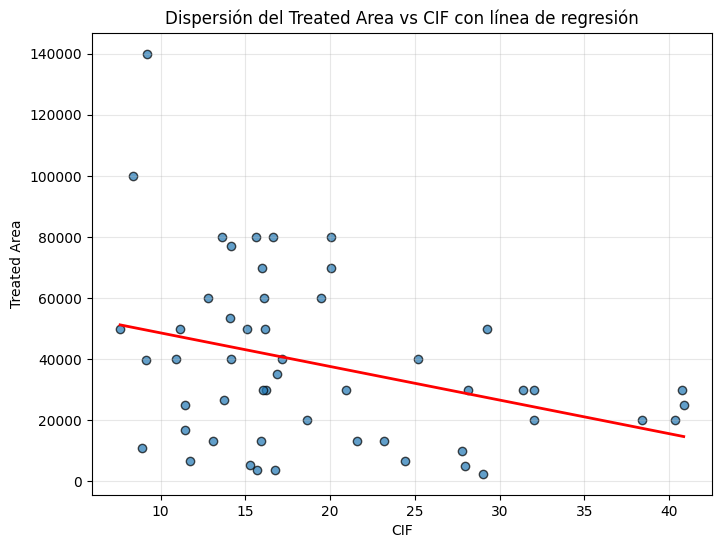

Coeficientes estimados (mínimos cuadrados):
Intercepto (constante): 59600.5763
Pendiente (cif): -1099.54913402

Interpretación:
- Intercepto: cuando CIF = 0, el treated_area esperado es 59600.5763.
- Pendiente: por cada unidad adicional de CIF, el treated_area cambia en -1099.54913402 unidades en promedio.

Evaluación del modelo:
R^2: 0.1150
F global: 6.4963
p-valor F global: 0.01393

Prueba t para cada coeficiente:
const: coef=59600.57627542, t=6.4739, p-valor=3.993e-08
cif: coef=-1099.54913402, t=-2.5488, p-valor=0.01393

Resumen del modelo:
                            OLS Regression Results                            
Dep. Variable:           treated_area   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     6.496
Date:                Mon, 27 Jul 2026   Prob (F-statistic):             0.0139
Time:                        23:44:17   Log-Likelihood:

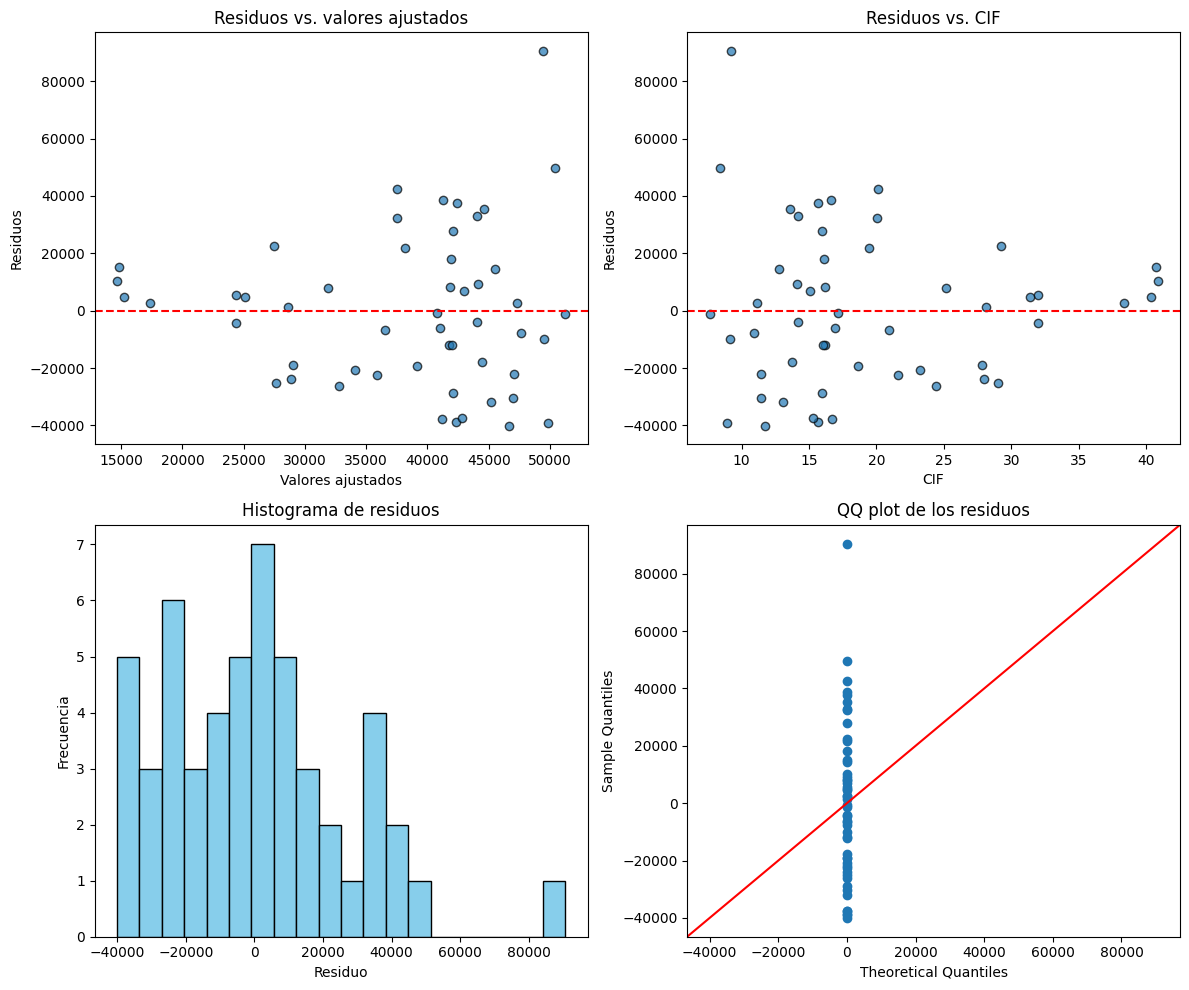

Durbin-Watson: 1.0169
Supuestos a revisar:
- Linealidad: los residuos deben dispersarse alrededor de cero sin patrón claro.
- Homocedasticidad: la varianza de los residuos debe ser aproximadamente constante.
- Normalidad: los residuos deben ajustarse a una distribución cercana a la normal.
- Independencia: Durbin-Watson cerca de 2 sugiere independencia de residuos.

Conclusión:
- Se ha ajustado una regresión lineal simple de treated_area en función de CIF.
- El coeficiente de pendiente indica la dirección del vínculo entre CIF y treated_area.
- El valor de R^2, la prueba F global y los p-valores de los coeficientes permitirán evaluar si el modelo es estadísticamente significativo.
- Los diagramas de residuos y el QQ plot permiten verificar los supuestos básicos del modelo.


In [44]:
import statsmodels.api as sm

# regresión lineal simple: treated_area ~ cif
y = data2['treated_area']
X = sm.add_constant(data2['cif'])
model_cif_to_area = sm.OLS(y, X).fit()

# diagrama de dispersión con línea de regresión
plt.figure(figsize=(8, 6))
plt.scatter(data2['cif'], data2['treated_area'], alpha=0.7, edgecolor='k')
x_line = np.linspace(data2['cif'].min(), data2['cif'].max(), 100)
y_line = model_cif_to_area.params['const'] + model_cif_to_area.params['cif'] * x_line
plt.plot(x_line, y_line, color='red', linewidth=2)
plt.title('Dispersión del Treated Area vs CIF con línea de regresión')
plt.xlabel('CIF')
plt.ylabel('Treated Area')
plt.grid(alpha=0.3)
plt.show()

# coeficientes e interpretación
intercept = model_cif_to_area.params['const']
slope = model_cif_to_area.params['cif']

print("Coeficientes estimados (mínimos cuadrados):")
print(f"Intercepto (constante): {intercept:.4f}")
print(f"Pendiente (cif): {slope:.8f}")
print()
print("Interpretación:")
print(f"- Intercepto: cuando CIF = 0, el treated_area esperado es {intercept:.4f}.")
print(f"- Pendiente: por cada unidad adicional de CIF, el treated_area cambia en {slope:.8f} unidades en promedio.")
print()

# evaluación del modelo
print("Evaluación del modelo:")
print(f"R^2: {model_cif_to_area.rsquared:.4f}")
print(f"F global: {model_cif_to_area.fvalue:.4f}")
print(f"p-valor F global: {model_cif_to_area.f_pvalue:.4g}")
print()

print("Prueba t para cada coeficiente:")
for name in model_cif_to_area.params.index:
    coef = model_cif_to_area.params[name]
    tval = model_cif_to_area.tvalues[name]
    pval = model_cif_to_area.pvalues[name]
    print(f"{name}: coef={coef:.8f}, t={tval:.4f}, p-valor={pval:.4g}")

print()
print("Resumen del modelo:")
print(model_cif_to_area.summary())

# residuos y gráficos de diagnóstico
fitted = model_cif_to_area.fittedvalues
residuals = model_cif_to_area.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(fitted, residuals, alpha=0.7, edgecolor='k')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuos vs. valores ajustados')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')

axes[0, 1].scatter(data2['cif'], residuals, alpha=0.7, edgecolor='k')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuos vs. CIF')
axes[0, 1].set_xlabel('CIF')
axes[0, 1].set_ylabel('Residuos')

axes[1, 0].hist(residuals, bins=20, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Histograma de residuos')
axes[1, 0].set_xlabel('Residuo')
axes[1, 0].set_ylabel('Frecuencia')

sm.qqplot(residuals, line='45', ax=axes[1, 1])
axes[1, 1].set_title('QQ plot de los residuos')

plt.tight_layout()
plt.show()

dw = sm.stats.stattools.durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")
print("Supuestos a revisar:")
print("- Linealidad: los residuos deben dispersarse alrededor de cero sin patrón claro.")
print("- Homocedasticidad: la varianza de los residuos debe ser aproximadamente constante.")
print("- Normalidad: los residuos deben ajustarse a una distribución cercana a la normal.")
print("- Independencia: Durbin-Watson cerca de 2 sugiere independencia de residuos.")
print()

print("Conclusión:")
print("- Se ha ajustado una regresión lineal simple de treated_area en función de CIF.")
print("- El coeficiente de pendiente indica la dirección del vínculo entre CIF y treated_area.")
print("- El valor de R^2, la prueba F global y los p-valores de los coeficientes permitirán evaluar si el modelo es estadísticamente significativo.")
print("- Los diagramas de residuos y el QQ plot permiten verificar los supuestos básicos del modelo.")

Coeficientes estimados (mínimos cuadrados):
Intercepto (constante): 23.4666
Pendiente (treated_area): -0.00010458

Interpretación:
- Intercepto: cuando treated_area = 0, el CIF esperado es 23.4666.
- Pendiente: por cada hectárea adicional tratada, el CIF cambia en -0.00010458 unidades en promedio.

Evaluación del modelo:
R^2: 0.1150
F global: 6.4963
p-valor F global: 0.01393

Prueba t para cada coeficiente:
const: coef=23.46664171, t=12.0315, p-valor=2.233e-16
treated_area: coef=-0.00010458, t=-2.5488, p-valor=0.01393

Resumen del modelo:
                            OLS Regression Results                            
Dep. Variable:                    cif   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     6.496
Date:                Mon, 27 Jul 2026   Prob (F-statistic):             0.0139
Time:                        23:33:36   Log-Likelihood:     

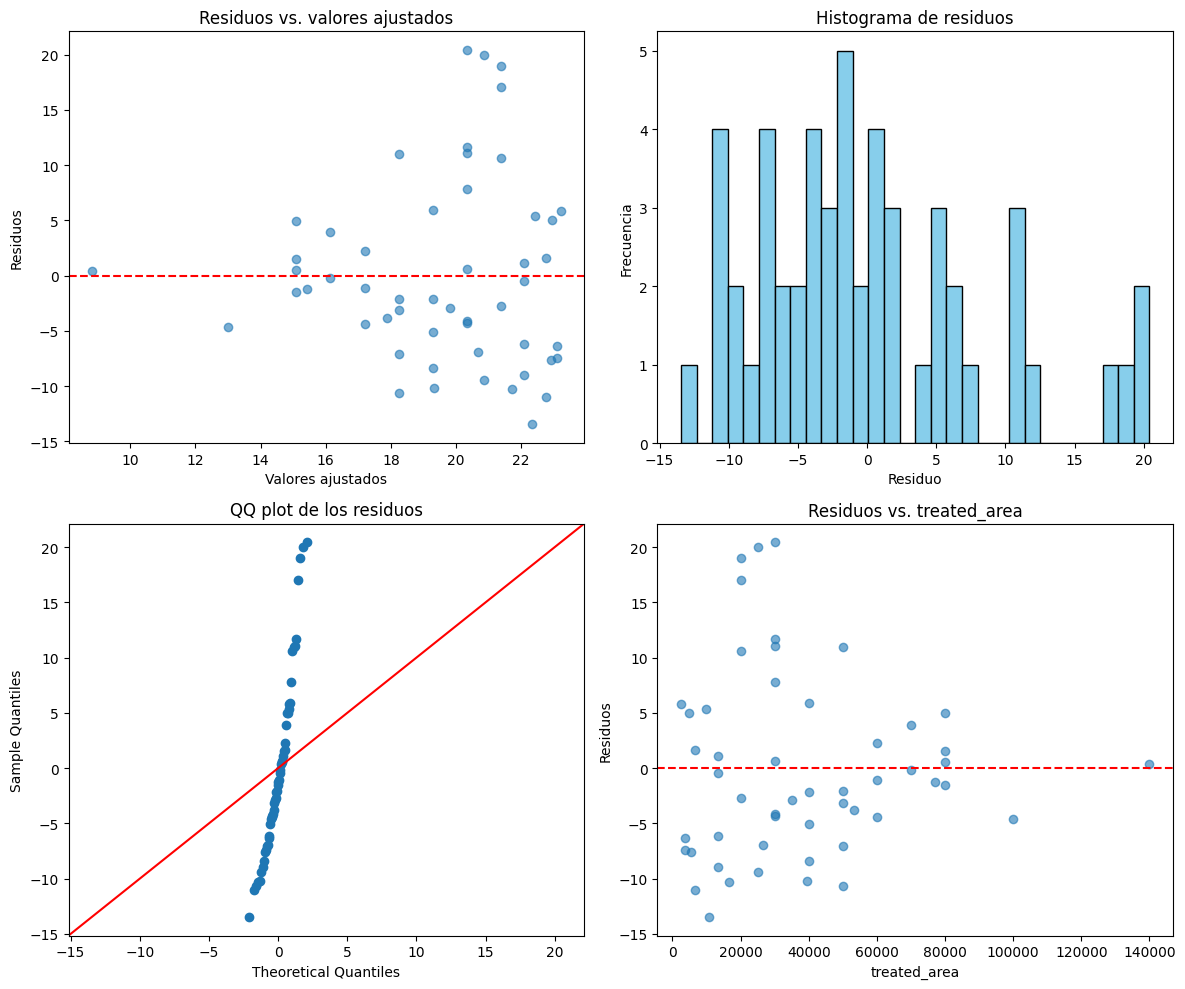

Durbin-Watson: 0.7695 (verifica independencia de residuos aproximada)
Supuestos a revisar:
- Linealidad: los residuos deben dispersarse alrededor de cero sin patrón.
- Homocedasticidad: la varianza de residuos debe ser aproximadamente constante.
- Normalidad: los residuos deben seguir una distribución cercana a la normal.


In [40]:
import statsmodels.api as sm

# definir variables
y = data2['cif']
X = sm.add_constant(data2['treated_area'])

# ajustar el modelo de regresión lineal simple
model = sm.OLS(y, X).fit()

# coeficientes
intercept = model.params['const']
slope = model.params['treated_area']

print("Coeficientes estimados (mínimos cuadrados):")
print(f"Intercepto (constante): {intercept:.4f}")
print(f"Pendiente (treated_area): {slope:.8f}")
print()
print("Interpretación:")
print(f"- Intercepto: cuando treated_area = 0, el CIF esperado es {intercept:.4f}.")
print(f"- Pendiente: por cada hectárea adicional tratada, el CIF cambia en {slope:.8f} unidades en promedio.")
print()

# evaluación del modelo
print("Evaluación del modelo:")
print(f"R^2: {model.rsquared:.4f}")
print(f"F global: {model.fvalue:.4f}")
print(f"p-valor F global: {model.f_pvalue:.4g}")
print()

print("Prueba t para cada coeficiente:")
for name in model.params.index:
    coef = model.params[name]
    tval = model.tvalues[name]
    pval = model.pvalues[name]
    print(f"{name}: coef={coef:.8f}, t={tval:.4f}, p-valor={pval:.4g}")

print()
print("Resumen del modelo:")
print(model.summary())

# residuos y valores ajustados
fitted = model.fittedvalues
residuals = model.resid

# gráficos de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(fitted, residuals, alpha=0.6)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuos vs. valores ajustados')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')

axes[0, 1].hist(residuals, bins=30, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Histograma de residuos')
axes[0, 1].set_xlabel('Residuo')
axes[0, 1].set_ylabel('Frecuencia')

sm.qqplot(residuals, line='45', ax=axes[1, 0])
axes[1, 0].set_title('QQ plot de los residuos')

axes[1, 1].scatter(data2['treated_area'], residuals, alpha=0.6)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Residuos vs. treated_area')
axes[1, 1].set_xlabel('treated_area')
axes[1, 1].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

# verificar supuestos básicos
dw = sm.stats.stattools.durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f} (verifica independencia de residuos aproximada)")
print("Supuestos a revisar:")
print("- Linealidad: los residuos deben dispersarse alrededor de cero sin patrón.")
print("- Homocedasticidad: la varianza de residuos debe ser aproximadamente constante.")
print("- Normalidad: los residuos deben seguir una distribución cercana a la normal.")